# OECD Ulkelerinde Dogurganlik Orani Analizi - EDA

**Bagimli degisken:** `fertility_rate`
**Bagimsiz degiskenler:** `inflation`, `unemployment_total`, `female_youth_unemployment_15_24`, `marriage_rate`
**Kategorik etiketler:** `region_tag`, `income_level`, `country_group`

**Kapsam:** 34 OECD ulkesi, 2000-2024, 850 satir, %100 dolu

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/processed/final_oecd.csv")
print(f"Shape: {df.shape}")
print(f"Sutunlar: {df.columns.tolist()}")
print(f"Yil araligi: {df['year'].min()} - {df['year'].max()}")
print(f"Ulke sayisi: {df['country_code'].nunique()}")
print(f"Eksik veri: {df.isnull().sum().sum()}")

Shape: (850, 13)
Sutunlar: ['country', 'country_code', 'year', 'fertility_rate', 'inflation', 'unemployment_total', 'female_youth_unemployment_15_24', 'marriage_rate', 'income_level', 'region_tag', 'country_group', 'marriage_rate_imputed', 'has_outlier']
Yil araligi: 2000 - 2024
Ulke sayisi: 34
Eksik veri: 0


## 1. Temel Istatistikler

In [2]:
print("=== VERI TIPLERI ===")
print(df.dtypes)
print()
print("=== ILK 5 SATIR ===")
df.head()

=== VERI TIPLERI ===
country                                str
country_code                           str
year                                 int64
fertility_rate                     float64
inflation                          float64
unemployment_total                 float64
female_youth_unemployment_15_24    float64
marriage_rate                      float64
income_level                           str
region_tag                             str
country_group                          str
marriage_rate_imputed                  str
has_outlier                           bool
dtype: object

=== ILK 5 SATIR ===


,country,country_code,year,fertility_rate,inflation,unemployment_total,female_youth_unemployment_15_24,marriage_rate,income_level,region_tag,country_group,marriage_rate_imputed,has_outlier
0,Australia,AUS,2000,1.756,4.457437,6.288,11.224,5.900,High income,Oceania,developed,original,False
1,Australia,AUS,2001,1.739,4.407130,6.747,12.282,5.300,High income,Oceania,developed,original,False
2,Australia,AUS,2002,1.756,2.981571,6.375,11.725,5.400,High income,Oceania,developed,original,False
3,Australia,AUS,2003,1.748,2.732598,5.933,11.281,5.348,High income,Oceania,developed,original,False
4,Australia,AUS,2004,1.768,2.343257,5.399,10.865,5.500,High income,Oceania,developed,original,False


In [3]:
print("=== TANIMLAYICI ISTATISTIKLER ===")
df.describe().round(3)

=== TANIMLAYICI ISTATISTIKLER ===


,year,fertility_rate,inflation,unemployment_total,female_youth_unemployment_15_24,marriage_rate
count,850.000,850.000,850.000,850.000,850.000,850.000
mean,2012.000,1.599,3.315,7.501,17.173,4.737
std,7.215,0.298,5.415,4.029,9.928,1.297
min,2000.000,0.721,-4.448,2.015,3.182,0.801
25%,2006.000,1.370,1.229,4.614,9.620,4.100
50%,2012.000,1.560,2.354,6.634,14.390,4.700
75%,2018.000,1.796,3.605,9.252,22.550,5.300
max,2024.000,2.714,72.309,27.686,64.309,9.500


## 2. Eksik Veri Analizi

Eksik veri yok!

marriage_rate_imputed dagilimi:
marriage_rate_imputed
original    756
median       65
mean         29
Name: count, dtype: int64


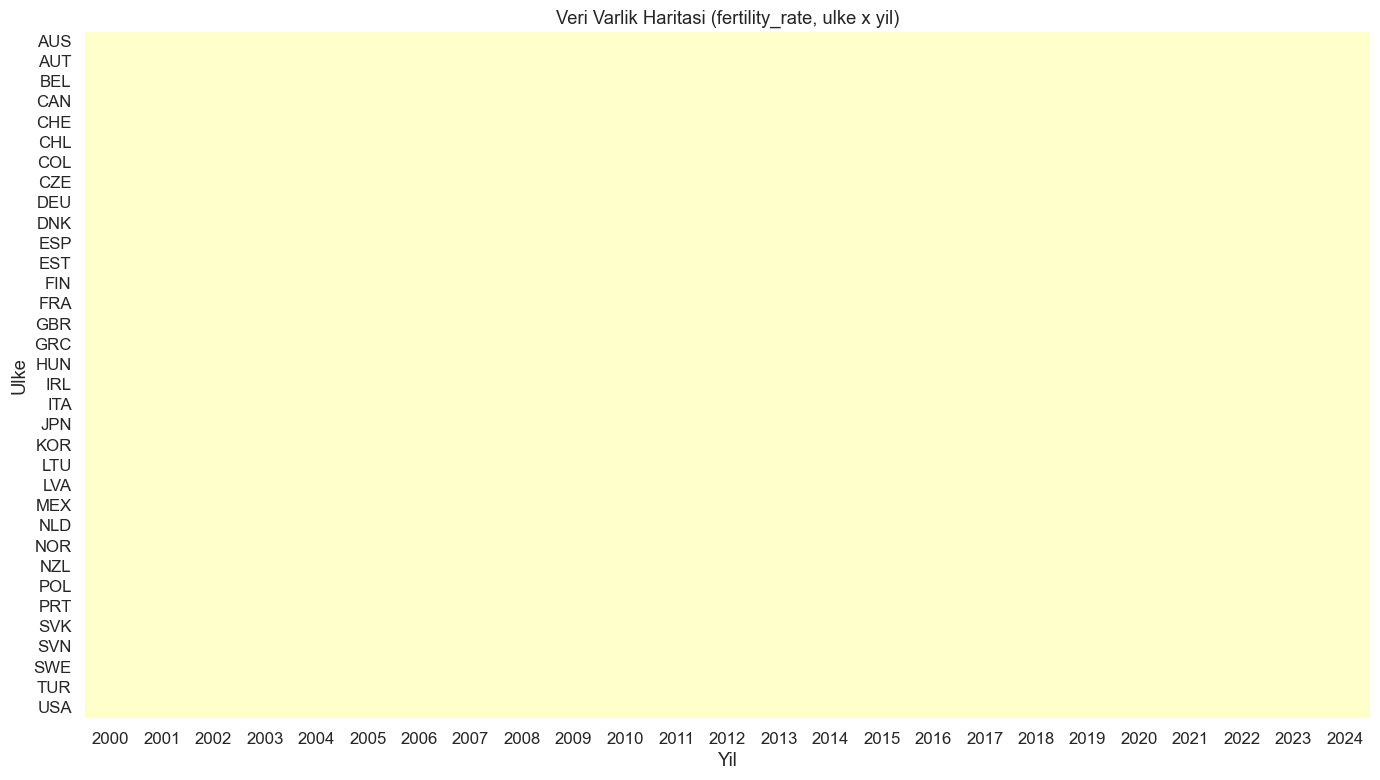

In [4]:
# Eksik veri sayisi ve orani
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Eksik Sayi": missing, "Eksik %": missing_pct})
print(missing_df[missing_df["Eksik Sayi"] > 0] if missing.sum() > 0 else "Eksik veri yok!")

# marriage_rate_imputed dagilimi
print("\nmarriage_rate_imputed dagilimi:")
print(df["marriage_rate_imputed"].value_counts())

# Eksik veri heatmap (ham verideki durumu gostermek icin)
fig, ax = plt.subplots(figsize=(14, 8))
pivot_missing = df.pivot_table(index="country_code", columns="year",
                               values="fertility_rate", aggfunc="count")
sns.heatmap(pivot_missing.isnull(), cbar=False, cmap="YlOrRd", ax=ax)
ax.set_title("Veri Varlik Haritasi (fertility_rate, ulke x yil)")
ax.set_xlabel("Yil")
ax.set_ylabel("Ulke")
plt.tight_layout()
plt.savefig("../outputs/missing_values_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Degisken Dagilimlari (Histogram + Boxplot)

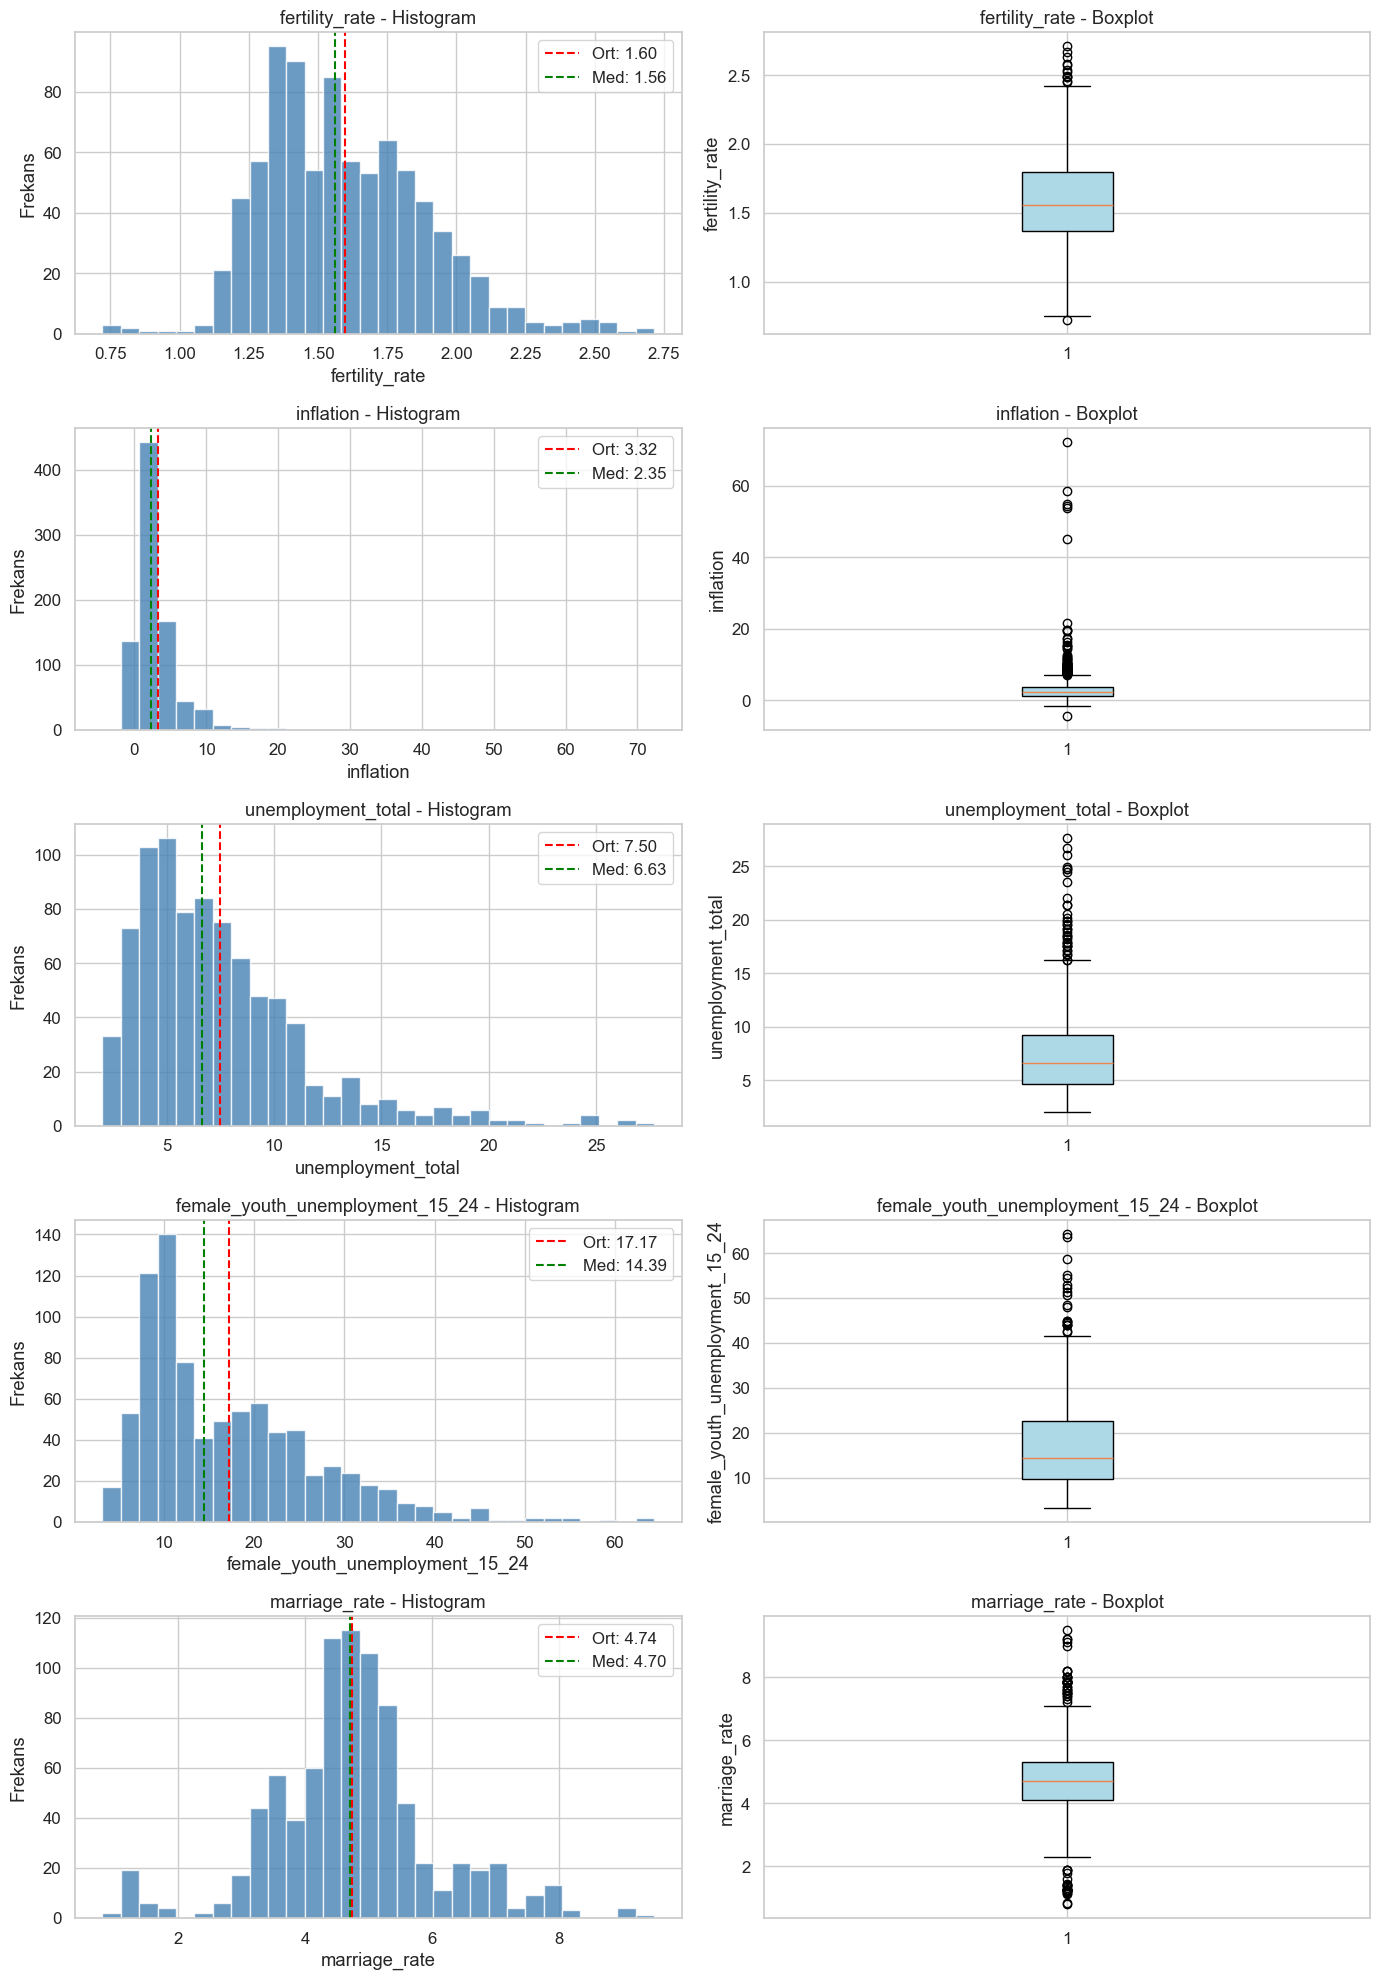

In [5]:
numeric_cols = ["fertility_rate", "inflation", "unemployment_total",
                "female_youth_unemployment_15_24", "marriage_rate"]

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()

    # Histogram
    axes[i, 0].hist(data, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i, 0].set_title(f"{col} - Histogram")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Frekans")
    axes[i, 0].axvline(data.mean(), color="red", linestyle="--", label=f"Ort: {data.mean():.2f}")
    axes[i, 0].axvline(data.median(), color="green", linestyle="--", label=f"Med: {data.median():.2f}")
    axes[i, 0].legend()

    # Boxplot
    axes[i, 1].boxplot(data, vert=True, patch_artist=True,
                        boxprops=dict(facecolor="lightblue"))
    axes[i, 1].set_title(f"{col} - Boxplot")
    axes[i, 1].set_ylabel(col)

plt.tight_layout()
plt.savefig("../outputs/distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Zaman Serisi: Bolge Bazli Dogurganlik Trendi

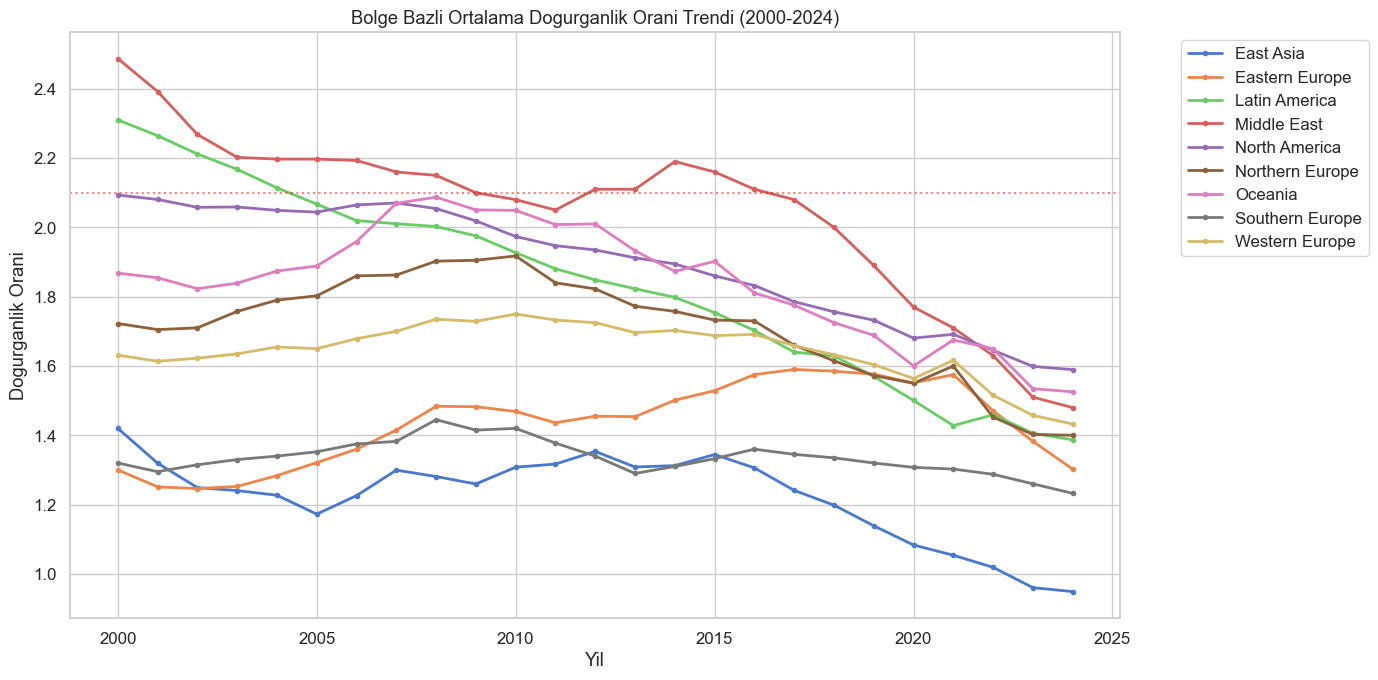

In [6]:
# Bolge bazli ortalama dogurganlik trendi
fig, ax = plt.subplots(figsize=(14, 7))

region_trend = df.groupby(["region_tag", "year"])["fertility_rate"].mean().reset_index()

for region in sorted(df["region_tag"].unique()):
    subset = region_trend[region_trend["region_tag"] == region]
    ax.plot(subset["year"], subset["fertility_rate"], marker="o", markersize=3, label=region, linewidth=2)

ax.set_title("Bolge Bazli Ortalama Dogurganlik Orani Trendi (2000-2024)")
ax.set_xlabel("Yil")
ax.set_ylabel("Dogurganlik Orani")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.axhline(y=2.1, color="red", linestyle=":", alpha=0.5, label="Yenileme duzeyi (2.1)")
plt.tight_layout()
plt.savefig("../outputs/fertility_trend_by_region.png", dpi=150, bbox_inches="tight")
plt.show()

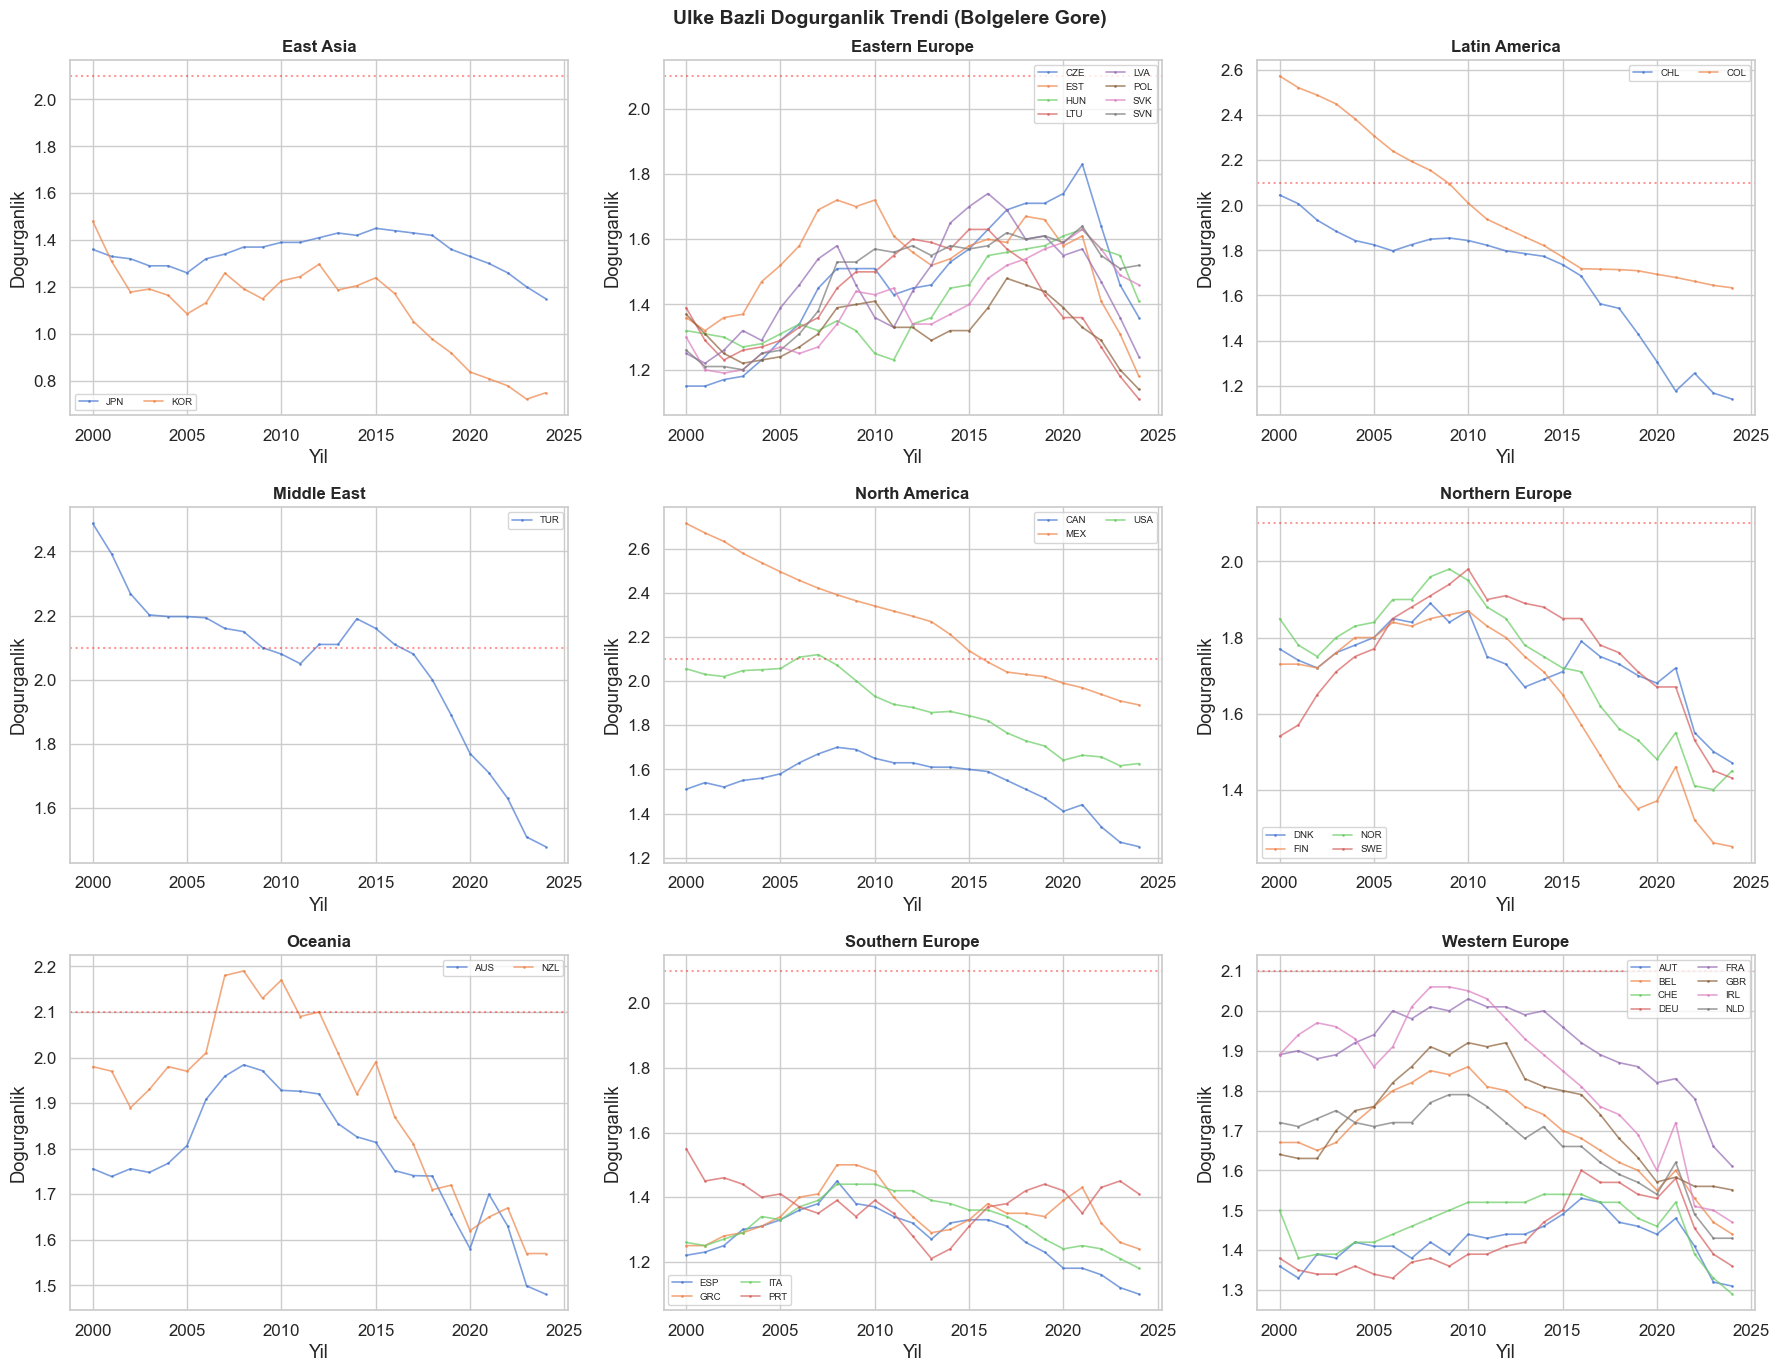

In [7]:
# Her ulke ayri ayri - bolge bazli facet grid
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
regions = sorted(df["region_tag"].unique())

for idx, region in enumerate(regions):
    ax = axes[idx // 3, idx % 3]
    subset = df[df["region_tag"] == region]

    for country in subset["country_code"].unique():
        country_data = subset[subset["country_code"] == country]
        ax.plot(country_data["year"], country_data["fertility_rate"],
                marker=".", markersize=2, alpha=0.7, label=country, linewidth=1.2)

    ax.set_title(region, fontsize=12, fontweight="bold")
    ax.set_xlabel("Yil")
    ax.set_ylabel("Dogurganlik")
    ax.legend(fontsize=7, ncol=2)
    ax.axhline(y=2.1, color="red", linestyle=":", alpha=0.4)

plt.suptitle("Ulke Bazli Dogurganlik Trendi (Bolgelere Gore)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/fertility_trend_by_country.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Korelasyon Matrisi

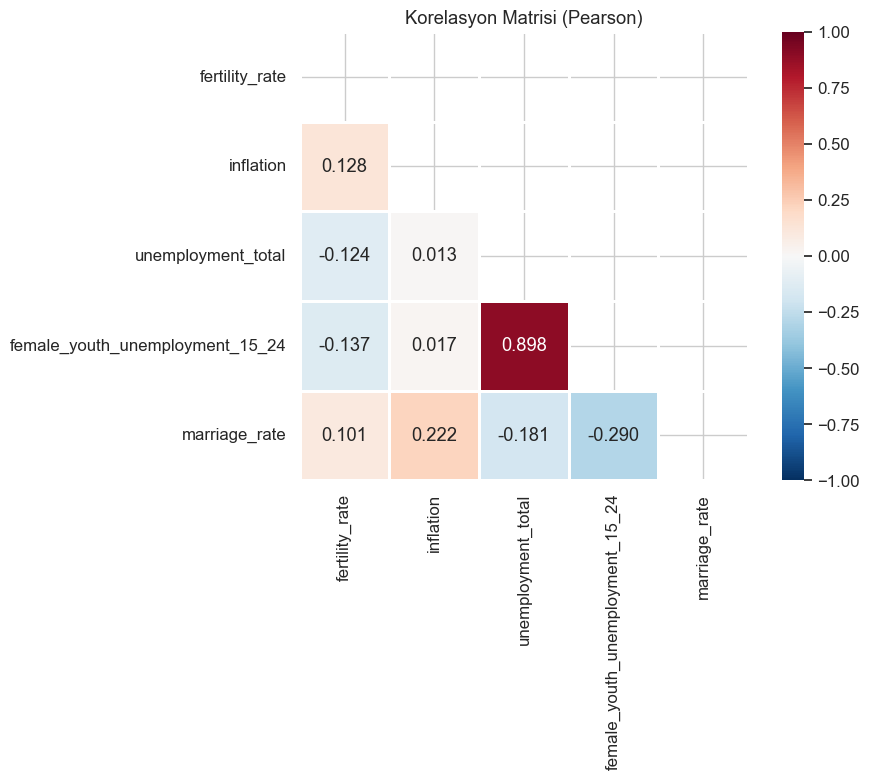


fertility_rate ile korelasyonlar:
fertility_rate                     1.0000
inflation                          0.1285
marriage_rate                      0.1009
unemployment_total                -0.1239
female_youth_unemployment_15_24   -0.1375
Name: fertility_rate, dtype: float64


In [8]:
numeric_cols = ["fertility_rate", "inflation", "unemployment_total",
                "female_youth_unemployment_15_24", "marriage_rate"]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".3f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=1, ax=ax)
ax.set_title("Korelasyon Matrisi (Pearson)")
plt.tight_layout()
plt.savefig("../outputs/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nfertility_rate ile korelasyonlar:")
print(corr_matrix["fertility_rate"].sort_values(ascending=False).round(4))

## 6. Scatter Plotlar: Dogurganlik vs Bagimsiz Degiskenler

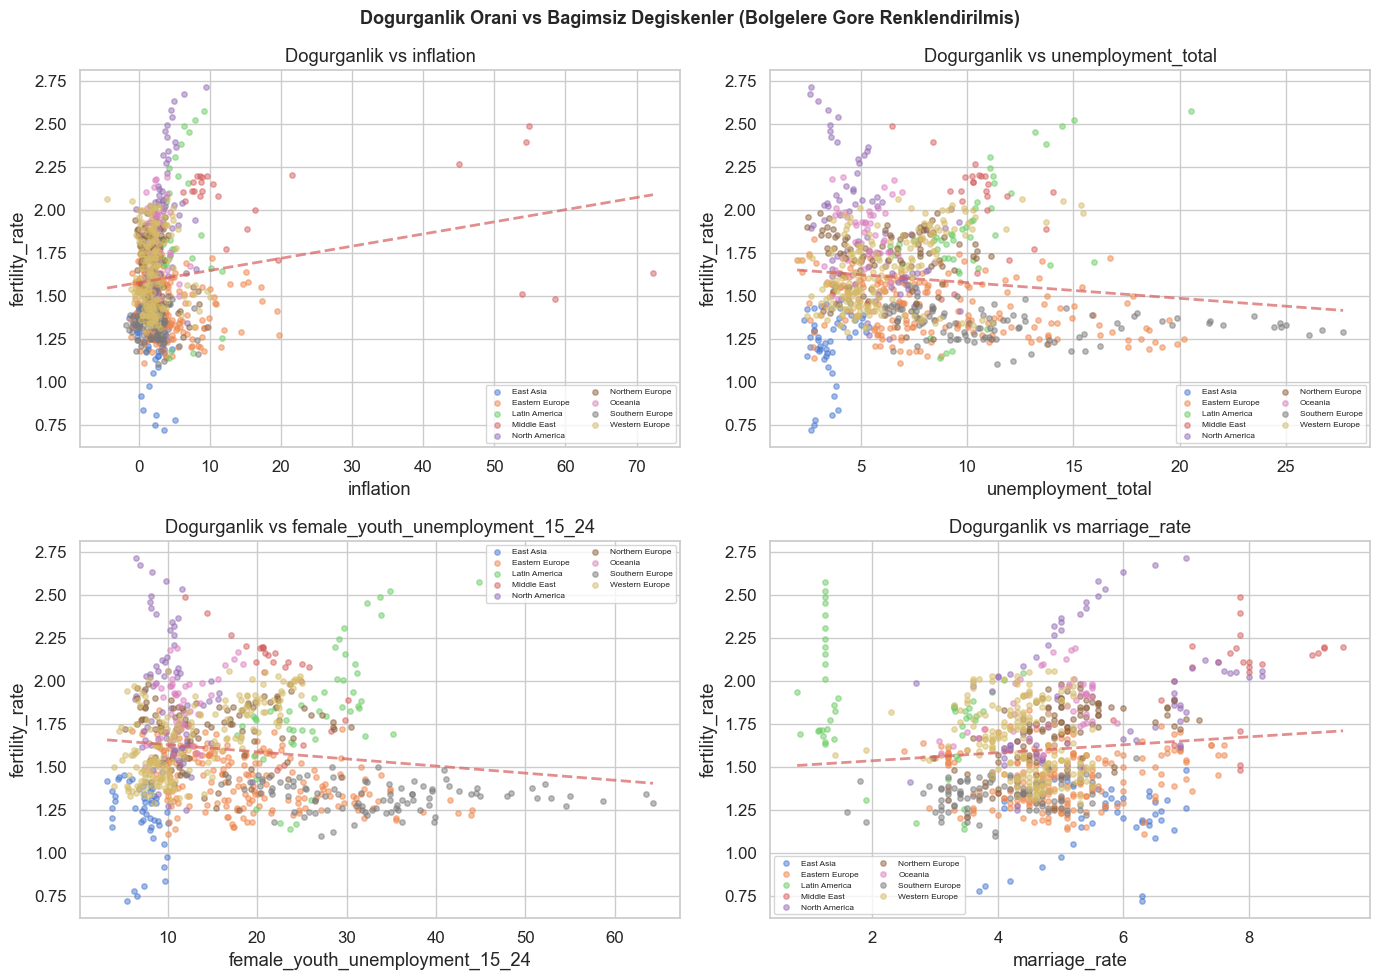

In [9]:
independent_vars = ["inflation", "unemployment_total",
                    "female_youth_unemployment_15_24", "marriage_rate"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(independent_vars):
    ax = axes[i]
    subset = df[["fertility_rate", var, "region_tag"]].dropna()

    for region in sorted(subset["region_tag"].unique()):
        region_data = subset[subset["region_tag"] == region]
        ax.scatter(region_data[var], region_data["fertility_rate"],
                   alpha=0.5, s=15, label=region)

    # Trend cizgisi
    clean = subset[["fertility_rate", var]].dropna()
    if len(clean) > 2:
        z = np.polyfit(clean[var], clean["fertility_rate"], 1)
        p = np.poly1d(z)
        x_line = np.linspace(clean[var].min(), clean[var].max(), 100)
        ax.plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.7)

    ax.set_xlabel(var)
    ax.set_ylabel("fertility_rate")
    ax.set_title(f"Dogurganlik vs {var}")
    ax.legend(fontsize=6, ncol=2)

plt.suptitle("Dogurganlik Orani vs Bagimsiz Degiskenler (Bolgelere Gore Renklendirilmis)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/scatter_fertility_vs_all.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Bolge ve Gelir Duzeyi Bazli Karsilastirmalar

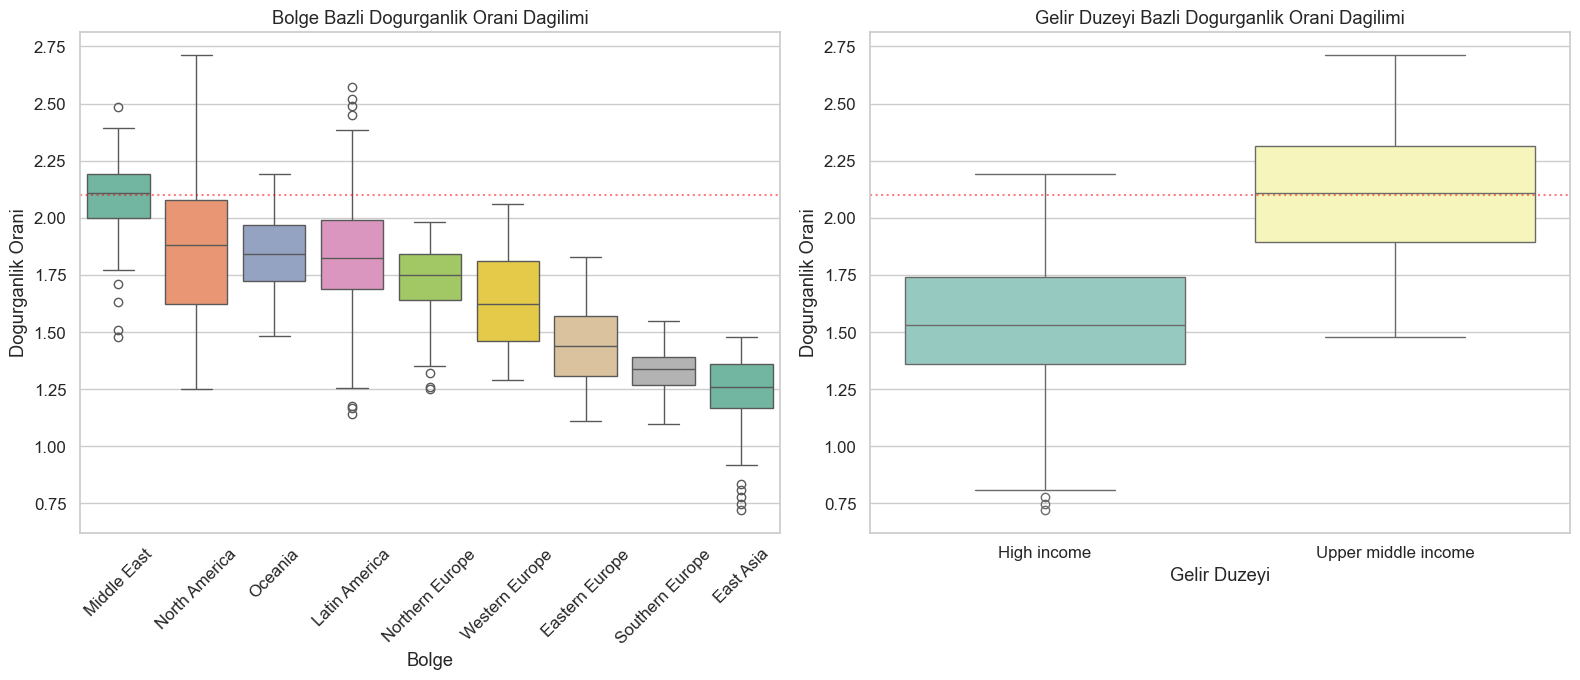

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bolge bazli dogurganlik boxplot
region_order = df.groupby("region_tag")["fertility_rate"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="region_tag", y="fertility_rate", order=region_order, ax=axes[0], palette="Set2")
axes[0].set_title("Bolge Bazli Dogurganlik Orani Dagilimi")
axes[0].set_xlabel("Bolge")
axes[0].set_ylabel("Dogurganlik Orani")
axes[0].tick_params(axis="x", rotation=45)
axes[0].axhline(y=2.1, color="red", linestyle=":", alpha=0.5)

# Gelir duzeyi bazli dogurganlik boxplot
sns.boxplot(data=df, x="income_level", y="fertility_rate", ax=axes[1], palette="Set3")
axes[1].set_title("Gelir Duzeyi Bazli Dogurganlik Orani Dagilimi")
axes[1].set_xlabel("Gelir Duzeyi")
axes[1].set_ylabel("Dogurganlik Orani")
axes[1].axhline(y=2.1, color="red", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("../outputs/boxplot_region_income.png", dpi=150, bbox_inches="tight")
plt.show()

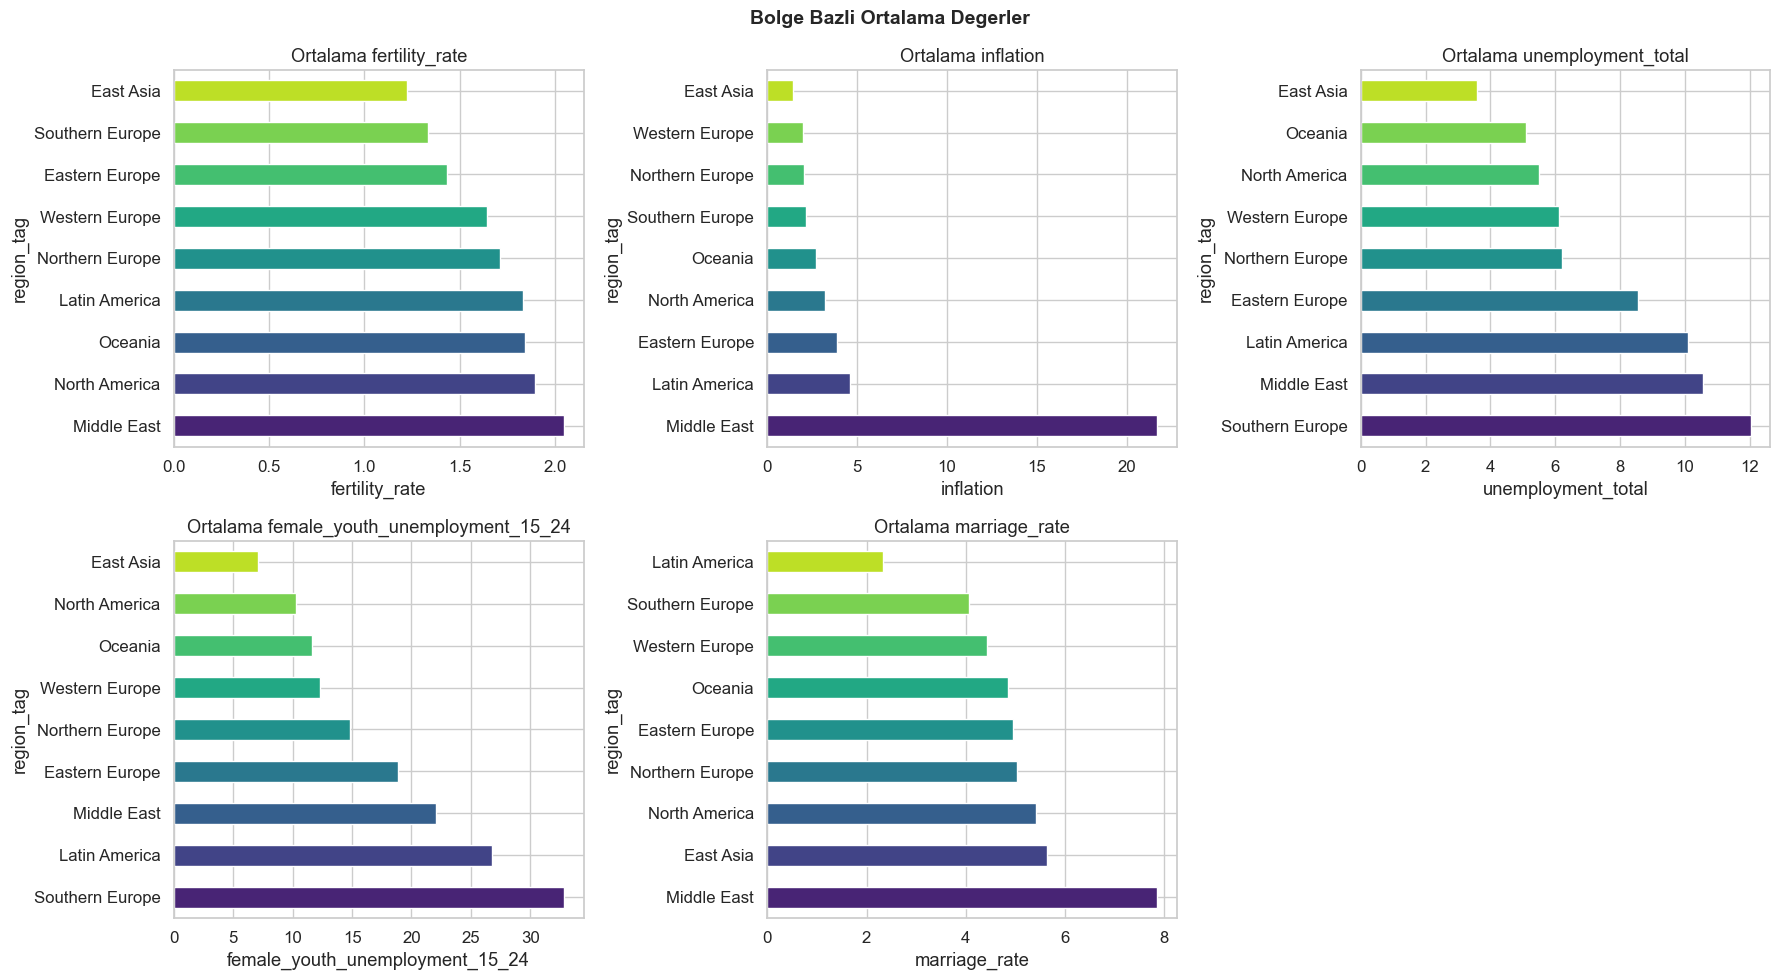

In [11]:
# Bolge bazli ortalama bar chart (tum degiskenler)
numeric_cols = ["fertility_rate", "inflation", "unemployment_total",
                "female_youth_unemployment_15_24", "marriage_rate"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for i, var in enumerate(numeric_cols):
    ax = axes_flat[i]
    means = df.groupby("region_tag")[var].mean().sort_values(ascending=False)
    means.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(means)))
    ax.set_title(f"Ortalama {var}")
    ax.set_xlabel(var)

axes_flat[5].set_visible(False)

plt.suptitle("Bolge Bazli Ortalama Degerler", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/bar_region_means.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Analiz Grubu (country_group) Bazli Karsilastirma

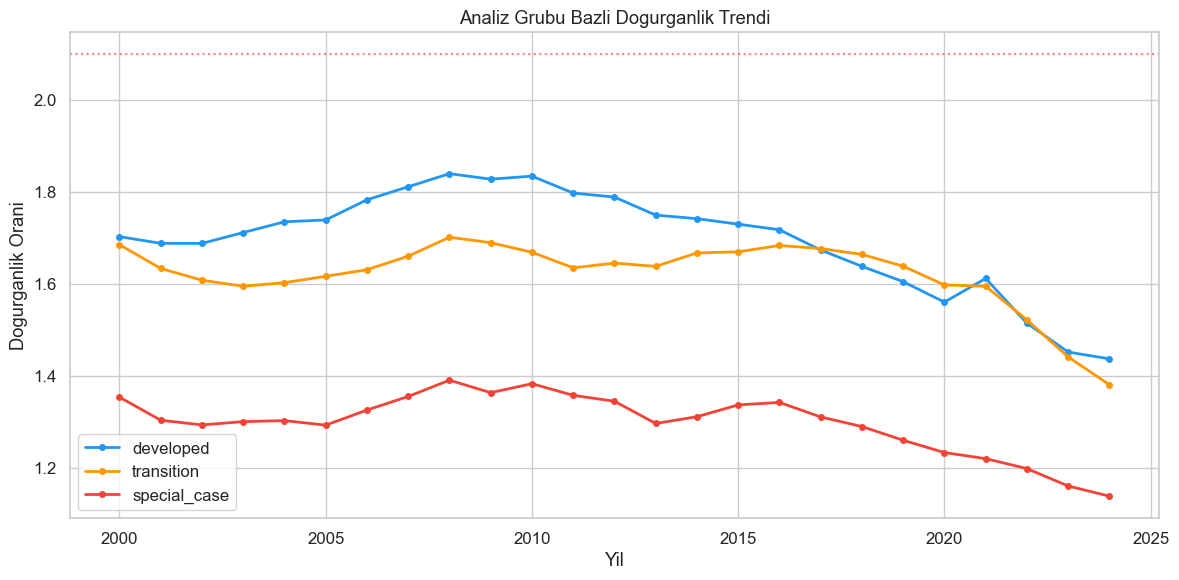

In [12]:
# Analiz grubu bazli dogurganlik trendi
fig, ax = plt.subplots(figsize=(12, 6))

group_trend = df.groupby(["country_group", "year"])["fertility_rate"].mean().reset_index()

colors = {"developed": "#2196F3", "transition": "#FF9800", "special_case": "#F44336"}
for group in ["developed", "transition", "special_case"]:
    subset = group_trend[group_trend["country_group"] == group]
    ax.plot(subset["year"], subset["fertility_rate"], marker="o", markersize=4,
            label=group, linewidth=2, color=colors[group])

ax.set_title("Analiz Grubu Bazli Dogurganlik Trendi")
ax.set_xlabel("Yil")
ax.set_ylabel("Dogurganlik Orani")
ax.legend()
ax.axhline(y=2.1, color="red", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("../outputs/fertility_trend_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

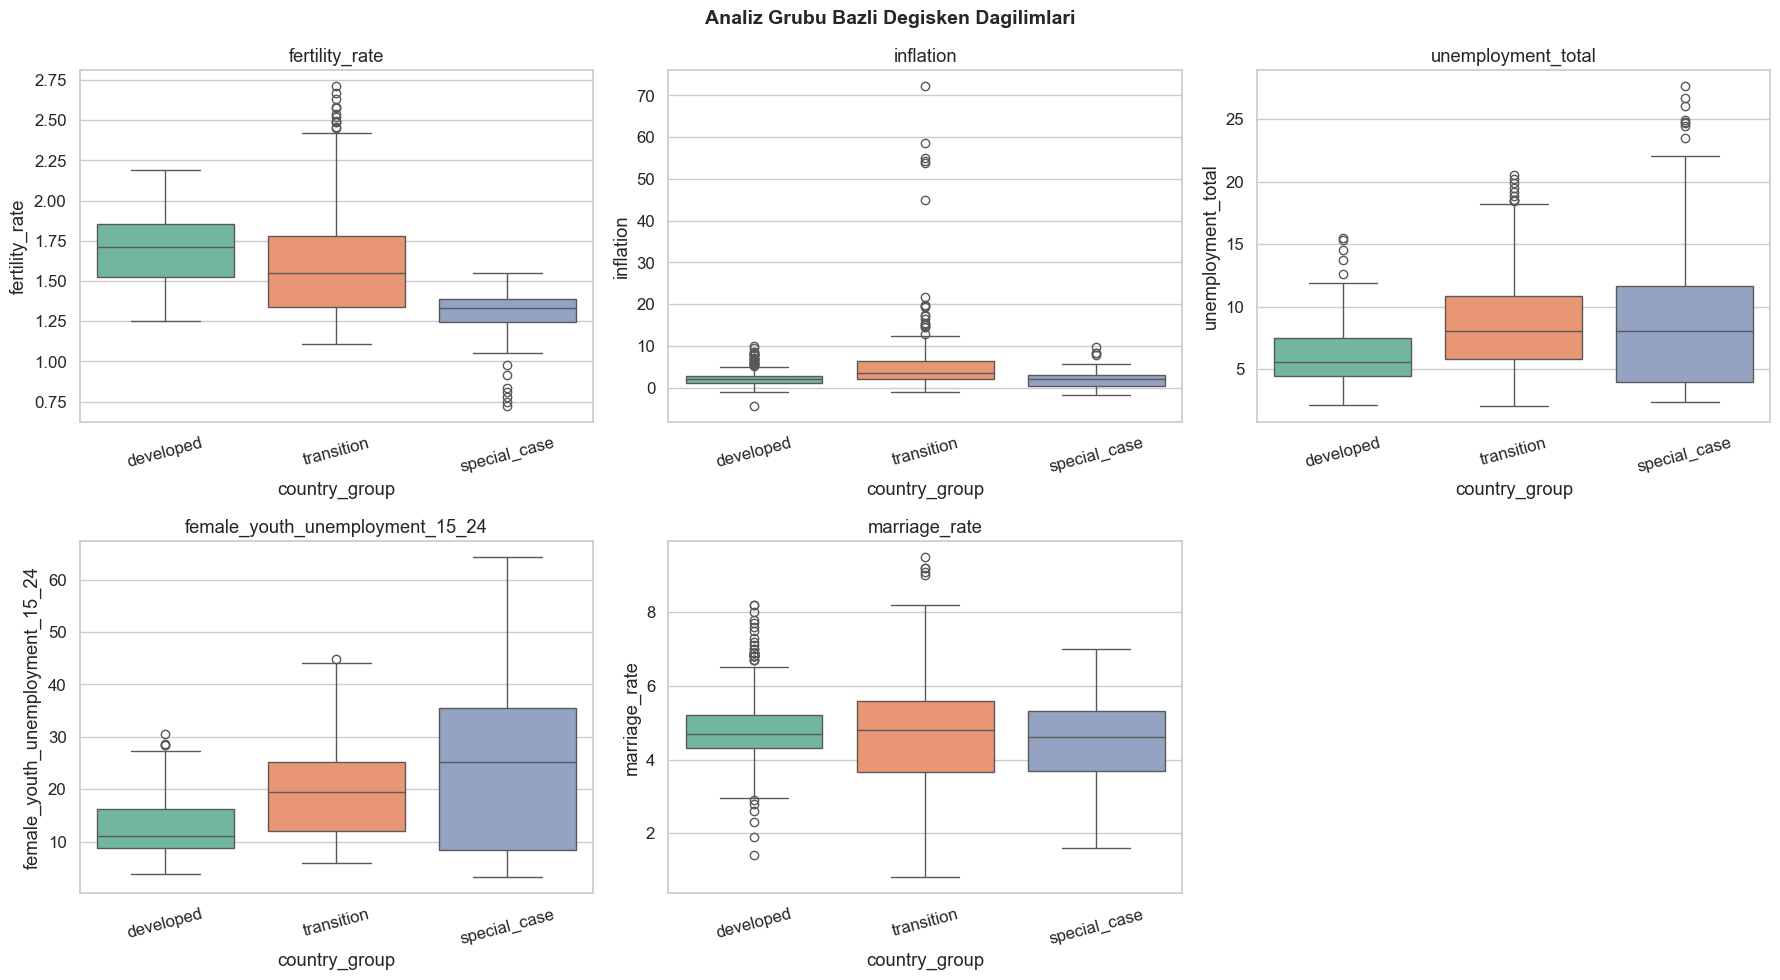

In [13]:
# Analiz grubu bazli boxplot - tum degiskenler
numeric_cols = ["fertility_rate", "inflation", "unemployment_total",
                "female_youth_unemployment_15_24", "marriage_rate"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for i, var in enumerate(numeric_cols):
    ax = axes_flat[i]
    sns.boxplot(data=df, x="country_group", y=var, ax=ax, palette="Set2",
                order=["developed", "transition", "special_case"])
    ax.set_title(var)
    ax.tick_params(axis="x", rotation=15)

axes_flat[5].set_visible(False)

plt.suptitle("Analiz Grubu Bazli Degisken Dagilimlari", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/boxplot_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Gelir duzeyi ve analiz grubu bazli ortalamalar
numeric_cols = ["fertility_rate", "inflation", "unemployment_total",
                "female_youth_unemployment_15_24", "marriage_rate"]

print("=== ANALIZ GRUBU BAZLI ORTALAMALAR ===")
group_summary = df.groupby("country_group")[numeric_cols].mean().round(3)
print(group_summary)
print()

print("=== GELIR DUZEYI BAZLI ORTALAMALAR ===")
income_summary = df.groupby("income_level")[numeric_cols].mean().round(3)
print(income_summary)
print()

print("=== BOLGE BAZLI ORTALAMALAR ===")
region_summary = df.groupby("region_tag")[numeric_cols].mean().round(3)
print(region_summary)

=== ANALIZ GRUBU BAZLI ORTALAMALAR ===
               fertility_rate  inflation  unemployment_total  \
country_group                                                  
developed               1.695      2.159               6.036   
special_case            1.298      1.938               9.220   
transition              1.622      5.546               8.594   

               female_youth_unemployment_15_24  marriage_rate  
country_group                                                  
developed                               12.679          4.781  
special_case                            24.266          4.591  
transition                              19.620          4.750  

=== GELIR DUZEYI BAZLI ORTALAMALAR ===
                     fertility_rate  inflation  unemployment_total  \
income_level                                                         
High income                   1.550      2.609               7.389   
Upper middle income           2.104     10.616               8.654   


## 9. Ozet

Bu EDA analizi sonucunda:
- Veri %100 dolu (850 satir, 13 sutun, 34 OECD ulkesi, 2000-2024)
- marriage_rate eksikleri ulke bazli mean/median imputation ile dolduruldu
- Outlier'lar tespit edildi ve `has_outlier` flag'i ile isaretlendi (silinmedi)
- Bolge, gelir duzeyi ve analiz grubu bazli karsilastirmalar yapildi
- Korelasyon matrisi ile degiskenler arasi iliskiler kesfedildi

**Sonraki adimlar:** Hipotez testleri, regresyon modelleri ve interaktif web sitesi.